Get Data

In [2]:

# Standard imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind
from google.colab import files
!pip install -q statsmodels
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd



In [17]:



# Upload the file
uploaded = files.upload()

# Load the file using row 3 as column headers
df = pd.read_excel('merged_edutopa_data.xlsx', header=2)

#df.head()

# USE MERGED_EDUTOPIA_DATA.XLSX FILE FOR THIS APRT

Saving merged_edutopa_data.xlsx to merged_edutopa_data (1).xlsx


P and T est on mode (1 +2) against mode 3


In [18]:
# Count how many users in each game mode
df['game_mode'].value_counts()


,count
game_mode,
2.0,11
1.0,10
3.0,8


In [19]:
# Group A: Gamified (Modes 1 & 2)
gamified = df[df['game_mode'].isin([1, 2])]['Pre and post Test Delta']
print("Gamified delta statistics:")
print(gamified.describe())
#print("Gamified delta values:")
#print(gamified)



# Group B: Traditional (Mode 3)
traditional = df[df['game_mode'] == 3]['Pre and post Test Delta']


Gamified delta statistics:
count    21.000000
mean      2.476190
std       2.337072
min      -2.000000
25%       1.000000
50%       2.000000
75%       4.000000
max       8.000000
Name: Pre and post Test Delta, dtype: float64


In [20]:
t_stat, p_val = ttest_ind(gamified.dropna(), traditional.dropna(), equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

T-statistic: 2.6048
P-value: 0.0186


T and P test between mode 1 and mode 2

In [21]:
mode1 = df[df['game_mode'] == 1]
mode2 = df[df['game_mode'] == 2]


group1_scores = mode1['quiz_correct_total'].dropna()
group2_scores = mode2['quiz_correct_total'].dropna()

# independent t-test
t_stat, p_val = ttest_ind(group1_scores, group2_scores, equal_var=False)

# results
print(" Mode 1 vs Mode 2 – Knowledge Retention")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")


 Mode 1 vs Mode 2 – Knowledge Retention
T-statistic: -0.6665
P-value: 0.5143


In [22]:
# Independent t-test between Mode 1 (Standard Gameplay) and Mode 3 (Traditional Learning)



# Filter data
mode1 = df[df['game_mode'] == 1]['Pre and post Test Delta']
mode3 = df[df['game_mode'] == 3]['Pre and post Test Delta']

# Remove missing values
mode1 = mode1.dropna()
mode3 = mode3.dropna()

# Run t-test
t_stat_13, p_val_13 = ttest_ind(mode1, mode3, equal_var=False)

# Display results
print(" Mode 1 vs  Mode 3")
print("T-statistic:", round(t_stat_13, 4))
print("P-value:", round(p_val_13, 4))


 Mode 1 vs  Mode 3
T-statistic: 1.6799
P-value: 0.1133


In [23]:
#  Independent t-test between Mode 2  and Mode 3



# Filter data
mode2 = df[df['game_mode'] == 2]['Pre and post Test Delta']
mode3 = df[df['game_mode'] == 3]['Pre and post Test Delta']

# Remove missing values
mode2 = mode2.dropna()
mode3 = mode3.dropna()

# Run t-test
t_stat_23, p_val_23 = ttest_ind(mode2, mode3, equal_var=False)

# Display results
print(" Mode 2 vs  Mode 3")
print("T-statistic:", round(t_stat_23, 4))
print("P-value:", round(p_val_23, 4))


 Mode 2 vs  Mode 3
T-statistic: 2.6693
P-value: 0.0162


In [24]:
#  Rename for formula compatibility
df = df.rename(columns={'Pre and post Test Delta': 'delta'})

#  Run ANOVA
model = ols('delta ~ C(game_mode)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== ANOVA Results ===")
print(anova_table)

#  Tukey Post-hoc (if needed)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n=== Tukey HSD Post-hoc Test ===")
tukey = pairwise_tukeyhsd(endog=df['delta'],
                          groups=df['game_mode'],
                          alpha=0.05)
print(tukey.summary())


=== ANOVA Results ===
                  sum_sq    df         F    PR(>F)
C(game_mode)   34.305564   2.0  3.644038  0.040262
Residual      122.384091  26.0       NaN       NaN

=== Tukey HSD Post-hoc Test ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
   1.0    2.0   1.2909   nan   nan   nan  False
   1.0    3.0   -1.425   nan   nan   nan  False
   1.0    nan      nan   nan   nan   nan  False
   2.0    3.0  -2.7159   nan   nan   nan  False
   2.0    nan      nan   nan   nan   nan  False
   3.0    nan      nan   nan   nan   nan  False
-----------------------------------------------


In [25]:
#  Import required libraries


#  STEP 1: Create new column for grouped learning types
df['learning_type'] = df['game_mode'].apply(lambda x: 'gamified' if x in [1, 2] else 'traditional')

#  STEP 2: Run ANOVA between learning types on knowledge delta
model = ols('delta ~ C(learning_type)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

#  STEP 3: Print Results
print("=== ANOVA: Gamified vs Traditional ===")
print(anova_table)


=== ANOVA: Gamified vs Traditional ===
                      sum_sq    df         F    PR(>F)
C(learning_type)   25.576560   1.0  5.266958  0.029733
Residual          131.113095  27.0       NaN       NaN


<ipython-input-26-189ac8ee8d0f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='game_mode', y='Knowledge Delta', data=df, palette='Set2')


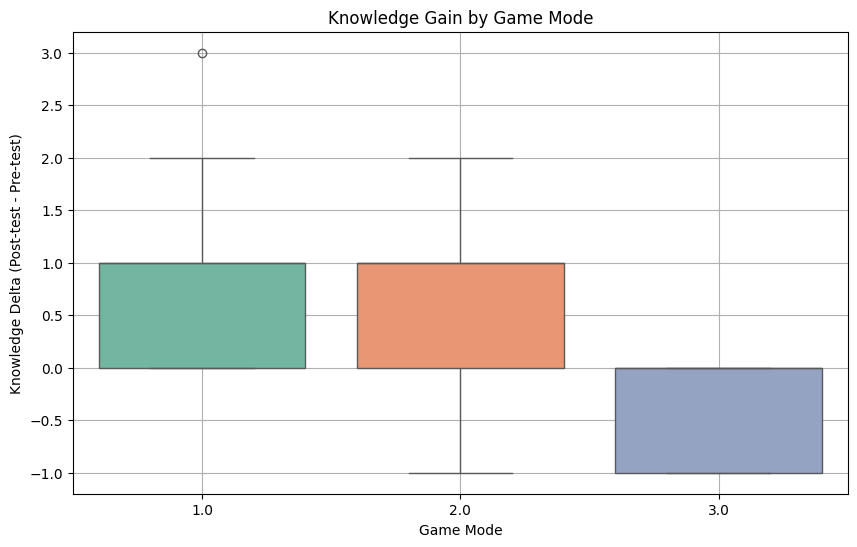

In [26]:
  # BOXPLOT: Knowledge Delta across Game Modes
  plt.figure(figsize=(10,6))
  sns.boxplot(x='game_mode', y='Knowledge Delta', data=df, palette='Set2')
  plt.xlabel('Game Mode')
  plt.ylabel('Knowledge Delta (Post-test - Pre-test)')
  plt.title('Knowledge Gain by Game Mode')
  plt.grid(True)
  plt.show()


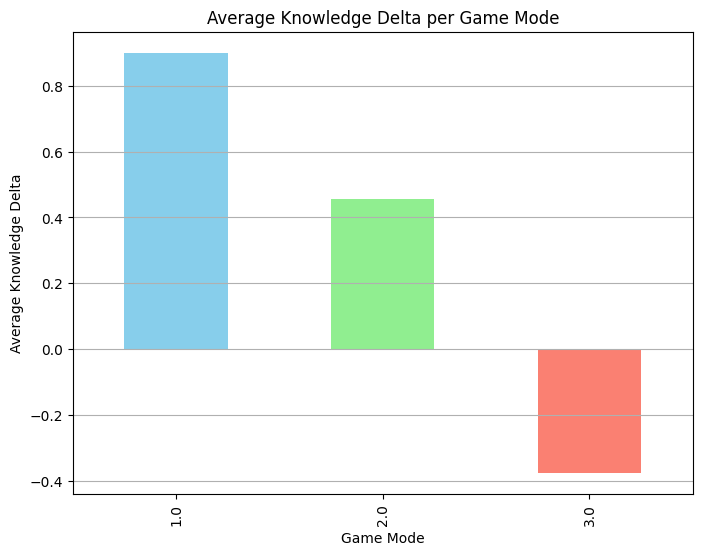

In [27]:
# BARPLOT: Mean Knowledge Delta
group_means = df.groupby('game_mode')['Knowledge Delta'].mean()

plt.figure(figsize=(8,6))
group_means.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Average Knowledge Delta per Game Mode')
plt.xlabel('Game Mode')
plt.ylabel('Average Knowledge Delta')
plt.grid(axis='y')
plt.show()


Motivation and Learning Experience Charts

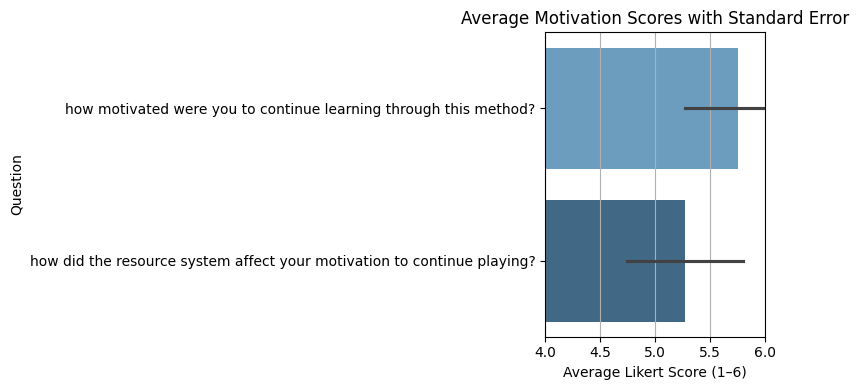

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1 — Select Motivation Likert questions
motivation_questions = [
    'how motivated were you to continue learning through this method?',
    'how did the resource system affect your motivation to continue playing?'
]

# Step 2 — Reshape for Seaborn
motivation_df = df[motivation_questions].melt(var_name='Question', value_name='Score')

# Step 3 — Plot with valid errorbar and hue fixes
plt.figure(figsize=(8, 4))
sns.barplot(
    data=motivation_df,
    x='Score',
    y='Question',
    hue='Question',                 # avoid palette warning
    palette='Blues_d',
    errorbar='se',                 # 'se' = standard error
    legend=False                   # suppress legend
)

plt.title("Average Motivation Scores with Standard Error")
plt.xlabel("Average Likert Score (1–6)")
plt.xlim(4, 6)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


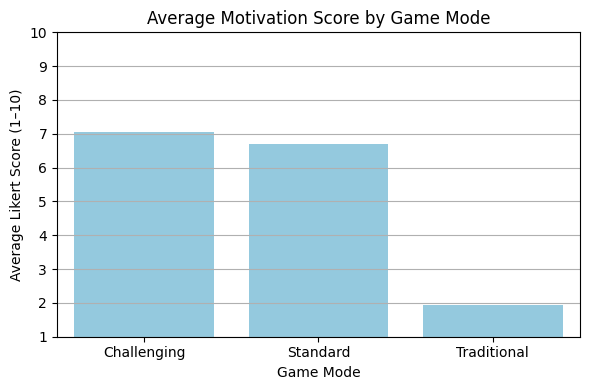

In [15]:


# Step 1: Map game_mode numbers to descriptive labels
game_mode_labels = {
    1: 'Standard',
    2: 'Challenging',
    3: 'Traditional'
}
df['game_mode_label'] = df['game_mode'].map(game_mode_labels)

# Step 2: Motivation questions to average
motivation_questions = [
    'how motivated were you to continue learning through this method?',
    'how did the resource system affect your motivation to continue playing?'
]

# Step 3: Calculate the average motivation score per participant
df['average_motivation'] = df[motivation_questions].mean(axis=1)

# Step 4: Group by game mode and compute the mean of the average motivation scores
summary = df.groupby('game_mode_label')['average_motivation'].mean().reset_index()

# Step 5: Plot the simplified bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x='game_mode_label', y='average_motivation', color='skyblue')


plt.title("Average Motivation Score by Game Mode")
plt.ylabel("Average Likert Score (1–10)")
plt.xlabel("Game Mode")
plt.ylim(1, 10)  # Adjust to highlight differences
plt.grid(axis='y')
plt.tight_layout()
plt.show()
